In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/sample_data/retail_sales_dataset.csv")

# Show first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Null values
print("\nNull Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Null Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Observation

- The dataset contains 1000 rows and 9 columns.
- There are no missing (null) values in any column.
- The dataset contains both numerical and categorical variables.
- Numerical columns include Age, Quantity, Price per Unit, and Total Amount.
- The Date column is currently stored as an object (string) and will be converted to datetime for time series analysis.

In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
print(df.mean(numeric_only=True))

print(df.median(numeric_only=True))

print(df.mode().iloc[0])

print(df.std(numeric_only=True))

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


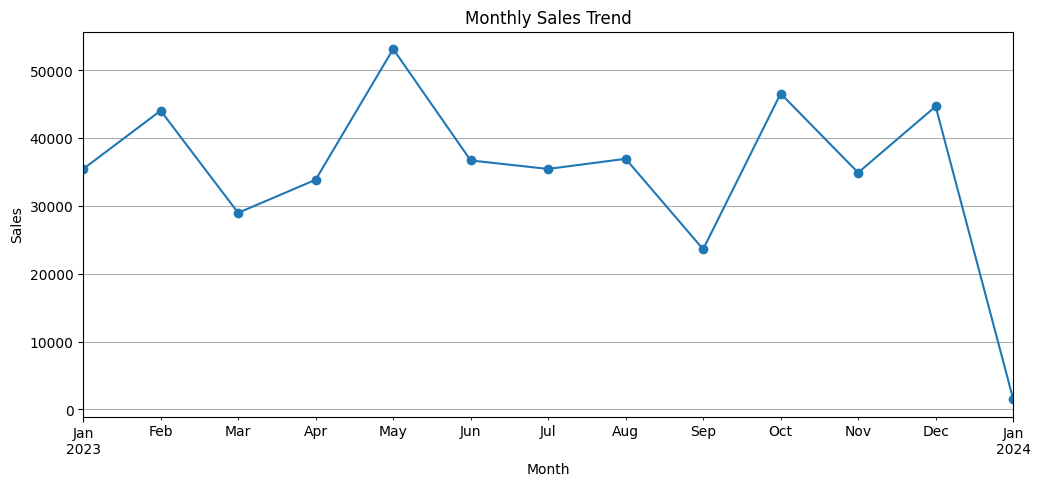

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Observation:

Monthly Sales fluctuate throughout the year. Sales are highest in May and October, while September records lower sales. The sharp drop in January 2024 is likely because the dataset contains only a few transactions for that month.

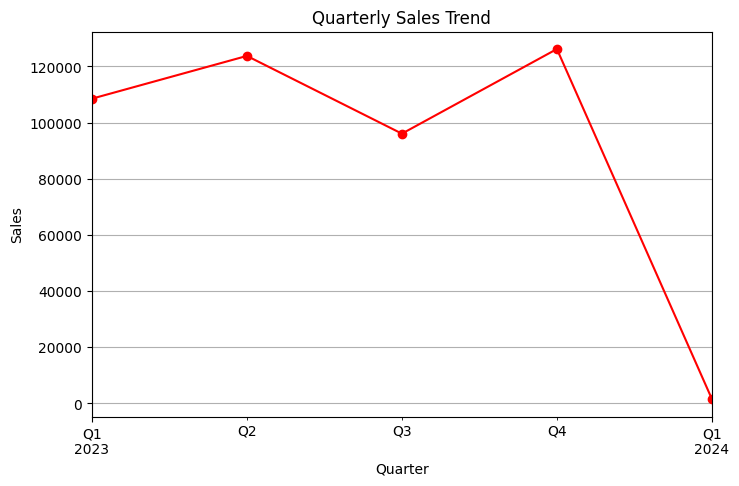

In [7]:
df["Quarter"] = df["Date"].dt.to_period("Q")

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(marker='o', color='red')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Observation:- Quarterly sales are highest in Q4 2023, followed closely by Q2 2023. Q3 2023 has comparatively lower sales, while the sharp decline in Q1 2024 is because the dataset contains only a small amount of data for that quarter.

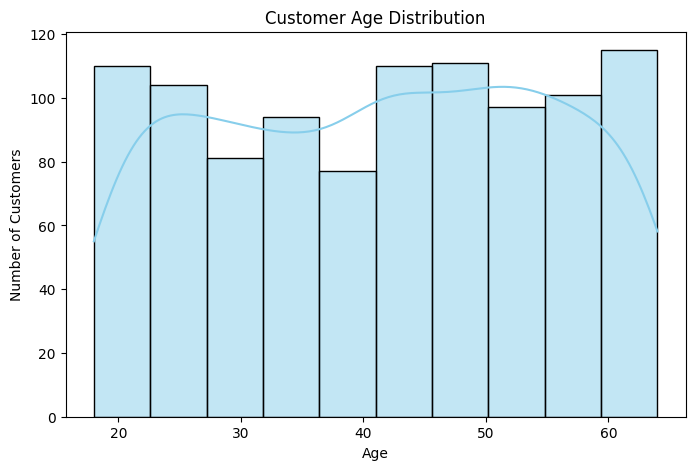

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True, color="skyblue")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Observation:- Most customers are between 30 and 50 years old. The customer age distribution is fairly balanced, indicating the business attracts customers from different age groups.

/tmp/ipykernel_3769/246982064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="Set2")


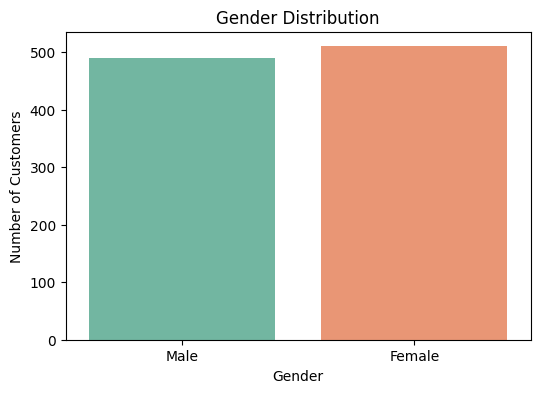

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df, palette="Set2")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

Observation:- Female customers make up a slightly larger percentage of the customer base than male customers, indicating that females are the dominant customer group in this dataset.

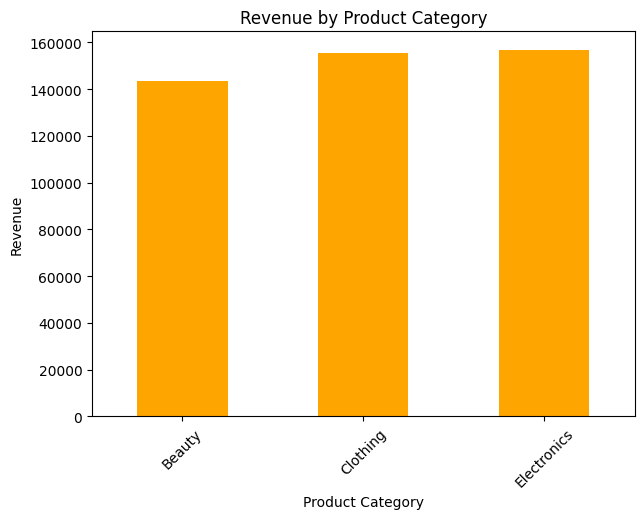

In [10]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar", color="orange")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Observation:-Electronics generated the highest revenue, followed by Clothing and Beauty. This indicates that Electronics is the strongest-performing product category and contributes the most to overall sales.

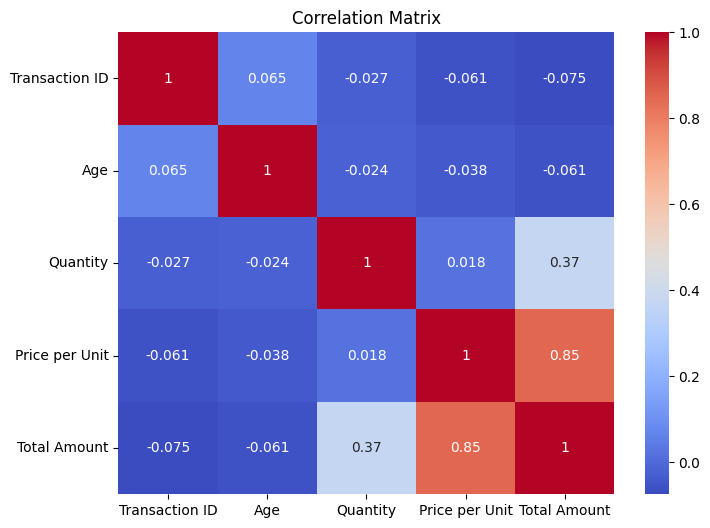

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Observation:-

- Price per Unit and Total Amount have a strong positive correlation (0.85), indicating that higher-priced products generate higher sales amounts.
- Quantity and Total Amount show a moderate positive correlation (0.37), meaning purchasing more items generally increases total sales.
- Customer Age has very weak correlation with other variables, suggesting age has little impact on purchasing behavior.

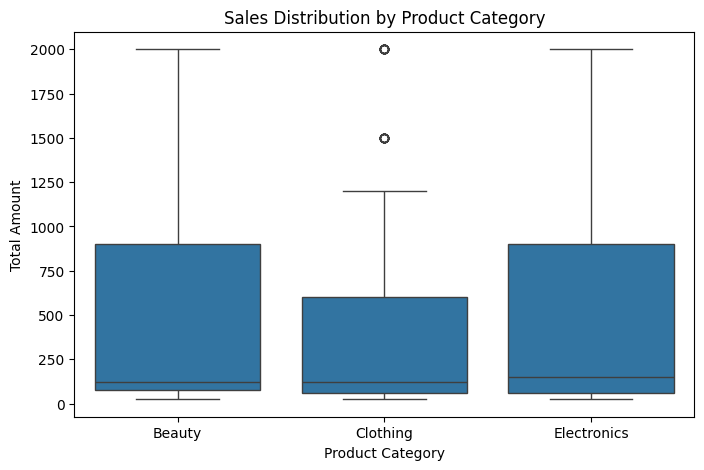

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Product Category", y="Total Amount", data=df)
plt.title("Sales Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

 Observation:-
- Electronics and Beauty have higher and more variable sales amounts than Clothing.
- Clothing generally has lower sales but includes a few high-value outlier transactions.
- The presence of outliers indicates that some purchases are significantly larger than the typical transaction.

Conclusion:-
This exploratory data analysis (EDA) provided valuable insights into customer purchasing behavior and retail sales performance. The analysis showed that sales fluctuate over time, with certain months and quarters generating higher revenue. Female customers slightly outnumber male customers, and most customers fall within the 30–50 age group. Electronics generated the highest revenue, followed by Clothing and Beauty. The correlation analysis showed a strong positive relationship between Price per Unit and Total Amount, while customer age had little impact on purchase value.

Business Recommendations:-

1. Increase inventory and promotional efforts for Electronics, as it is the highest revenue-generating category.
2. Launch targeted marketing campaigns for the 30–50 age group and female customers, who form a significant portion of the customer base.
3. Analyze high-value transactions and seasonal sales trends to optimize pricing, inventory planning, and future marketing strategies.